# Brain Tumor YOLO — Training Run Analysis

This notebook documents and compares all training runs for the YOLOv11s brain tumor detector.

**Story arc:**
- **Run 1** established the baseline on imbalanced data. Glioma overconfidence was the dominant failure mode.
- **Run 2** tested `label_smoothing=0.1` — no effect (symmetric operation, insensitive to class distribution).
- **Run 3** applied oversampling (meningioma+pituitary → glioma parity). All global metrics improved; best.pt saved at epoch 36 with severe oscillation for the remaining 64 epochs, indicating LR instability.
- **Run 4+** add `cos_lr=True` and reduce `patience=15` to fix the oscillation.

All sections auto-detect available runs from `runs/brain_tumor/*/results.csv` — no run names are hardcoded.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
RUNS_DIR = ROOT / 'runs' / 'brain_tumor'

# Auto-detect all runs that have a results.csv
run_csvs = sorted(RUNS_DIR.glob('*/results.csv'), key=lambda p: p.parent.name)
run_names = [p.parent.name for p in run_csvs]
print(f'Detected runs: {run_names}')

Detected runs: ['yolo11s_29_04_1620', 'yolo11s_29_04_1759', 'yolo11s_29_04_2007']


---
## Section 1 — Run Configuration

Fixed parameters shared across all runs, plus the single change introduced in each run.
The fixed block is stable by design — only the per-run change column should vary.

In [2]:
fixed_config = {
    'epochs': 100,
    'imgsz': 640,
    'batch': 16,
    'amp': True,
    'patience': '20 → 15 (Run 4+)',
    'fliplr': 0.5,
    'flipud': 0.0,
    'degrees': 10.0,
    'mosaic': 0.5,
    'mixup': 0.0,
    'hsv_v': 0.2,
    'hsv_s': 0.0,
    'close_mosaic': 10,
    'cos_lr': 'False → True (Run 4+)',
}

per_run_changes = {
    'yolo11s_29_04_1620': 'Baseline — no class weights, default dataset',
    'yolo11s_29_04_1759': 'label_smoothing=0.1 added',
    'yolo11s_29_04_2007': 'Oversampling: meningioma 552→1087, pituitary 767→1087 (seed=42)',
}

print('=== Fixed Training Configuration ===')
df_fixed = pd.DataFrame(list(fixed_config.items()), columns=['Parameter', 'Value'])
display(df_fixed.style.hide(axis='index'))

print('\n=== Per-Run Key Change ===')
rows = []
for name in run_names:
    change = per_run_changes.get(name, '(not documented)')
    rows.append({'Run': name, 'Key Change': change})
display(pd.DataFrame(rows).style.hide(axis='index'))

=== Fixed Training Configuration ===


Parameter,Value
epochs,100
imgsz,640
batch,16
amp,True
patience,20 → 15 (Run 4+)
fliplr,0.500000
flipud,0.000000
degrees,10.000000
mosaic,0.500000
mixup,0.000000



=== Per-Run Key Change ===


Run,Key Change
yolo11s_29_04_1620,"Baseline — no class weights, default dataset"
yolo11s_29_04_1759,label_smoothing=0.1 added
yolo11s_29_04_2007,"Oversampling: meningioma 552→1087, pituitary 767→1087 (seed=42)"


---
## Section 2 — Learning Curves (mAP over epochs)

Overlapping mAP@0.50 and mAP@0.5:0.95 for all runs on the same axes.

**What to look for:**
- Which run reaches peak mAP earliest (convergence speed).
- Whether later runs sustain high mAP or oscillate after the peak (LR stability).
- Gap between mAP@0.50 and mAP@0.5:0.95 indicates localisation precision at stricter IoU thresholds.

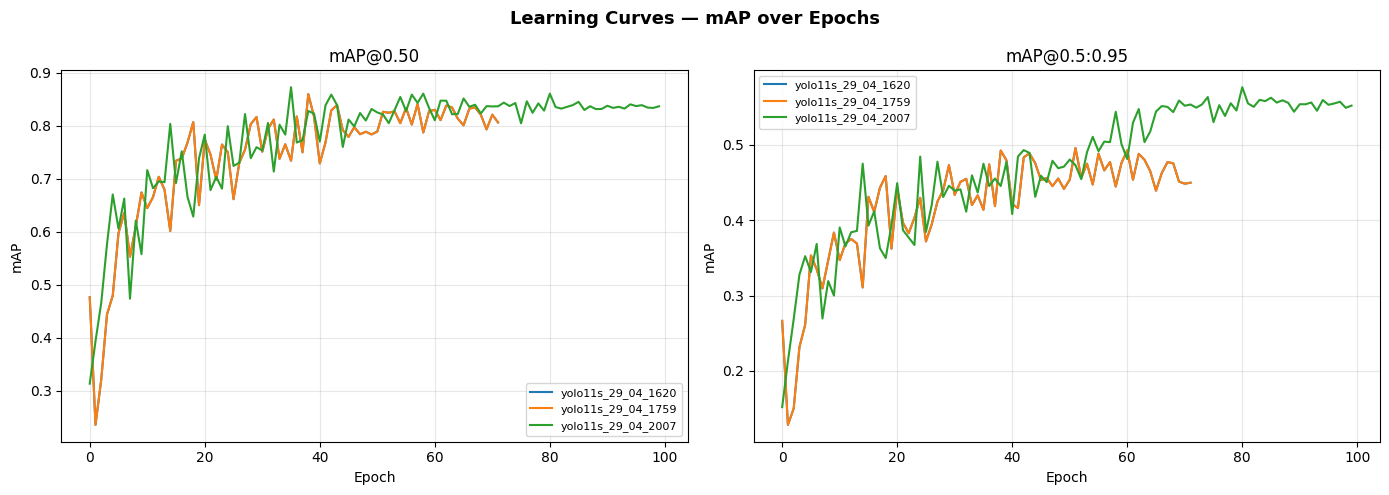

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax50, ax95 = axes

colors = plt.cm.tab10.colors

for i, (csv_path, name) in enumerate(zip(run_csvs, run_names)):
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        color = colors[i % len(colors)]
        if 'metrics/mAP50(B)' in df.columns:
            ax50.plot(df['metrics/mAP50(B)'], label=name, color=color)
        if 'metrics/mAP50-95(B)' in df.columns:
            ax95.plot(df['metrics/mAP50-95(B)'], label=name, color=color)
    except Exception as e:
        print(f'Skipping {name}: {e}')

for ax, title in [(ax50, 'mAP@0.50'), (ax95, 'mAP@0.5:0.95')]:
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Learning Curves — mAP over Epochs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Loss Curves (Train vs Validation)

One figure per run. Each figure has two subplots:
- **Box loss**: bounding-box regression quality.
- **Classification loss**: class prediction confidence.

**What to look for:**
- Train/val loss should track closely. A large divergence signals overfitting.
- Oscillation in val loss after the best epoch marks where patience triggers early stopping.
- A smooth cosine decay (`cos_lr=True`) should show monotonically decreasing loss without late-epoch spikes.

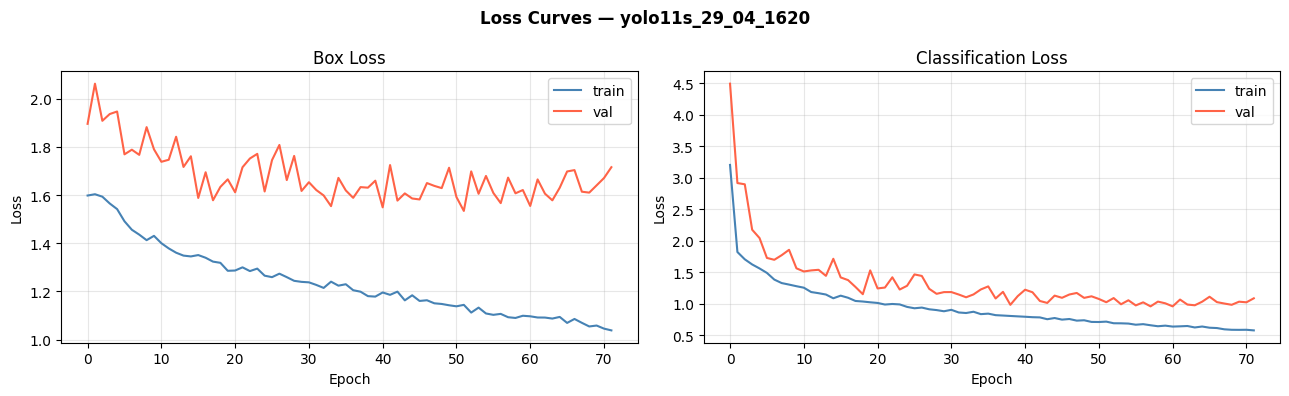

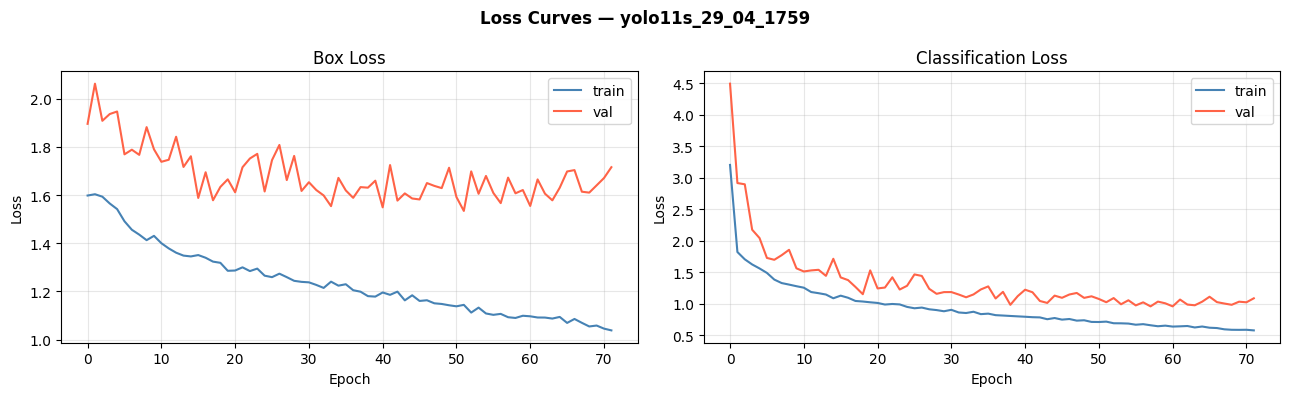

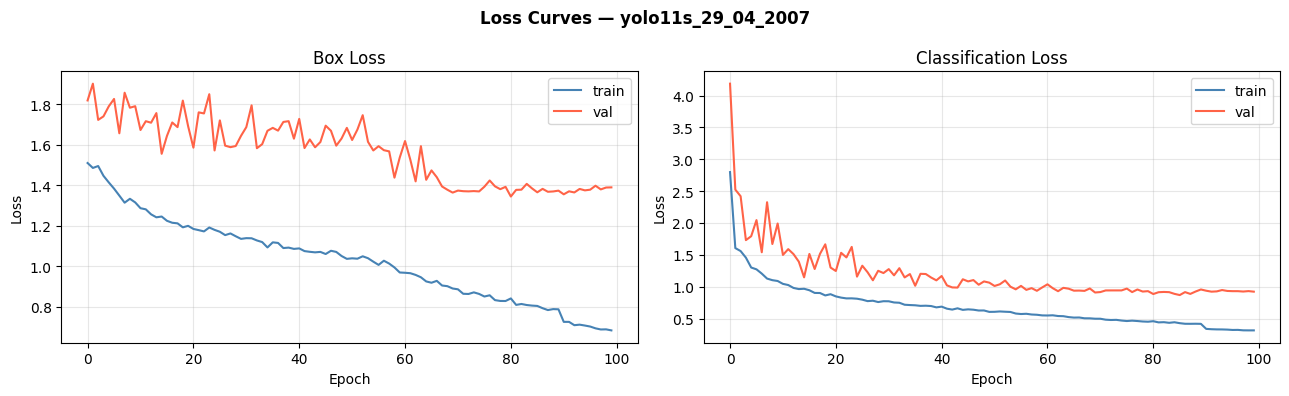

In [4]:
for csv_path, name in zip(run_csvs, run_names):
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        has_box = 'train/box_loss' in df.columns and 'val/box_loss' in df.columns
        has_cls = 'train/cls_loss' in df.columns and 'val/cls_loss' in df.columns

        if not has_box and not has_cls:
            print(f'{name}: loss columns not found, skipping.')
            continue

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f'Loss Curves — {name}', fontsize=12, fontweight='bold')

        if has_box:
            axes[0].plot(df['train/box_loss'], label='train', color='steelblue')
            axes[0].plot(df['val/box_loss'], label='val', color='tomato')
            axes[0].set_title('Box Loss')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

        if has_cls:
            axes[1].plot(df['train/cls_loss'], label='train', color='steelblue')
            axes[1].plot(df['val/cls_loss'], label='val', color='tomato')
            axes[1].set_title('Classification Loss')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Loss')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'{name}: error — {e}')

---
## Section 4 — Convergence Analysis

Per run: best epoch (argmax of mAP@0.50), whether early stopping triggered, and total training time.

**What to look for:**
- A low best epoch relative to total epochs means the model peaked early and burned compute on a degrading plateau.
- `cos_lr=True` should push the best epoch later and reduce wasted epochs.

In [5]:
rows = []
for csv_path, name in zip(run_csvs, run_names):
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        best_epoch = None
        if 'metrics/mAP50(B)' in df.columns:
            best_epoch = int(df['metrics/mAP50(B)'].idxmax()) + 1  # 1-based

        total_epochs = len(df)
        early_stopped = total_epochs < 100  # configured max is 100

        total_time_str = 'N/A'
        time_col = next((c for c in df.columns if 'time' in c.lower()), None)
        if time_col:
            total_secs = df[time_col].sum()
            h, rem = divmod(int(total_secs), 3600)
            m, s = divmod(rem, 60)
            total_time_str = f'{h:02d}h {m:02d}m {s:02d}s'

        rows.append({
            'Run': name,
            'Best Epoch': best_epoch if best_epoch else 'N/A',
            'Epochs Run': total_epochs,
            'Early Stopped': 'Yes' if early_stopped else 'No',
            'Total Train Time': total_time_str,
        })
    except Exception as e:
        print(f'{name}: error — {e}')

if rows:
    display(pd.DataFrame(rows).style.hide(axis='index'))
else:
    print('No convergence data available.')

Run,Best Epoch,Epochs Run,Early Stopped,Total Train Time
yolo11s_29_04_1620,39,72,Yes,21h 00m 56s
yolo11s_29_04_1759,39,72,Yes,21h 02m 54s
yolo11s_29_04_2007,36,100,No,52h 36m 24s


---
## Section 5 — Global Metrics Comparison

Grouped bar chart comparing mAP@0.50, mAP@0.5:0.95, Precision, and Recall across all completed runs.

**What to look for:**
- mAP@0.5:0.95 is the strictest and most informative metric — it rewards precise localisation.
- A run can show identical mAP@0.50 while differing significantly in mAP@0.5:0.95 (as seen in Runs 1 vs 3).
- Recall improvements indicate the model misses fewer tumours — critical for medical use.

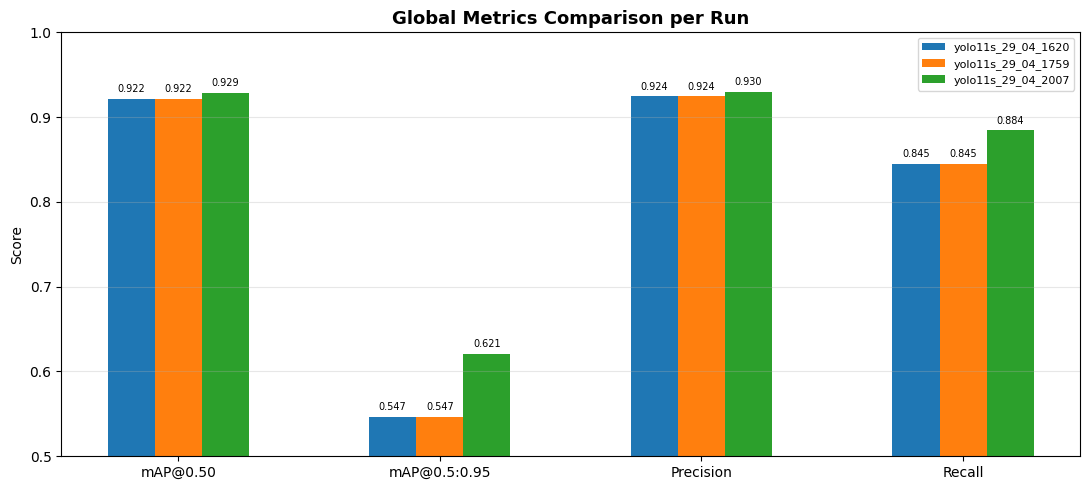

In [6]:
# Hardcoded from run_analysis.md (Runs 1-3 confirmed; pending runs excluded)
known_metrics = {
    'yolo11s_29_04_1620': {'mAP@0.50': 0.9217, 'mAP@0.5:0.95': 0.5468, 'Precision': 0.9244, 'Recall': 0.8453},
    'yolo11s_29_04_1759': {'mAP@0.50': 0.9217, 'mAP@0.5:0.95': 0.5468, 'Precision': 0.9244, 'Recall': 0.8453},
    'yolo11s_29_04_2007': {'mAP@0.50': 0.9290, 'mAP@0.5:0.95': 0.6212, 'Precision': 0.9301, 'Recall': 0.8844},
}

# Only include runs that exist on disk AND have known metrics
plot_runs = [n for n in run_names if n in known_metrics]

if not plot_runs:
    print('No runs with known metrics available for plotting.')
else:
    metric_keys = ['mAP@0.50', 'mAP@0.5:0.95', 'Precision', 'Recall']
    n_runs = len(plot_runs)
    n_metrics = len(metric_keys)
    bar_width = 0.18
    x = range(n_metrics)

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = plt.cm.tab10.colors

    for i, name in enumerate(plot_runs):
        vals = [known_metrics[name][k] for k in metric_keys]
        offsets = [xi + i * bar_width - (n_runs - 1) * bar_width / 2 for xi in x]
        bars = ax.bar(offsets, vals, width=bar_width, label=name, color=colors[i % len(colors)])
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(list(x))
    ax.set_xticklabels(metric_keys)
    ax.set_ylabel('Score')
    ax.set_ylim(0.5, 1.0)
    ax.set_title('Global Metrics Comparison per Run', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Section 6 — Confusion Matrices Side by Side

Normalised confusion matrices from the test split evaluation (`eval_test/confusion_matrix_normalized.png`).

**What to look for:**
- Diagonal values are true positive rates per class. Higher is better.
- Off-diagonal cells show which classes the model confuses. The persistent Background→Glioma cell is the key failure mode across runs.
- Oversampling (Run 3) should visibly improve meningioma and pituitary diagonal values while the background→glioma bias persists.

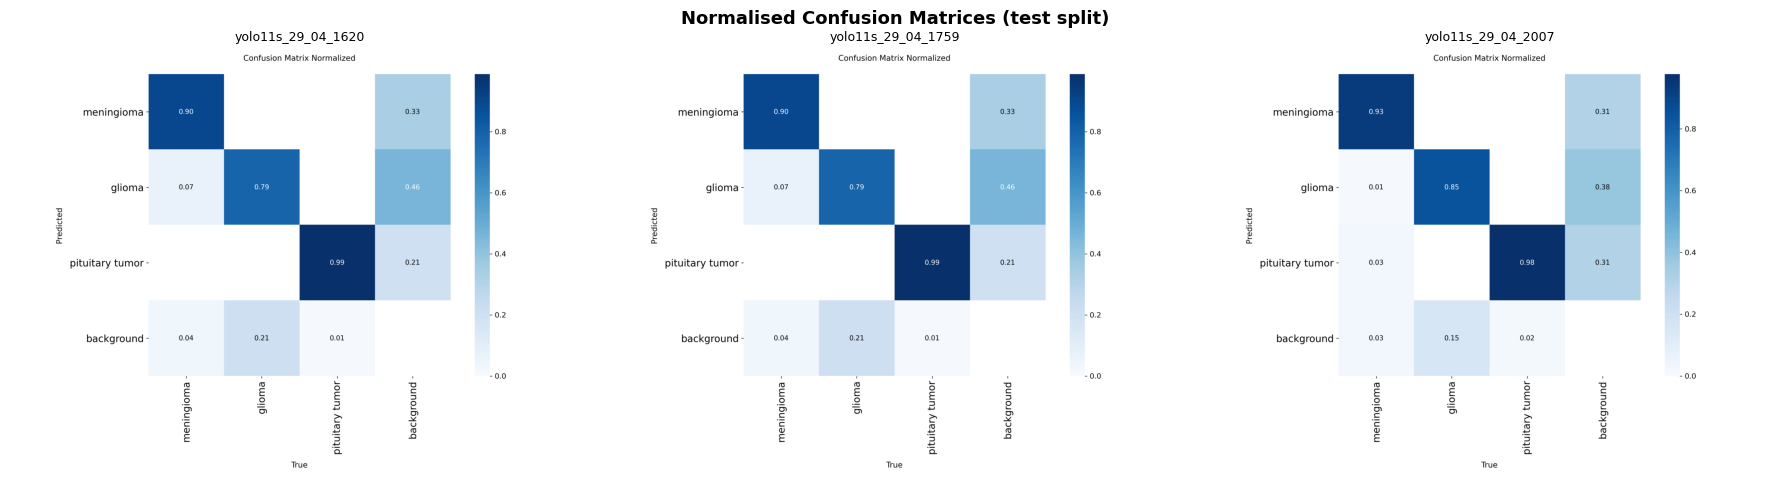

In [7]:
cm_paths = []
cm_names = []
for name in run_names:
    p = RUNS_DIR / name / 'eval_test' / 'confusion_matrix_normalized.png'
    if p.exists():
        cm_paths.append(p)
        cm_names.append(name)

if not cm_paths:
    print('No confusion matrix images found. Run evaluate.py for each run first.')
else:
    n = len(cm_paths)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, path, name in zip(axes, cm_paths, cm_names):
        img = mpimg.imread(str(path))
        ax.imshow(img)
        ax.set_title(name, fontsize=9)
        ax.axis('off')
    fig.suptitle('Normalised Confusion Matrices (test split)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Section 7 — F1-Confidence Curves

F1 score as a function of confidence threshold for each run (`eval_test/F1_curve.png`).

**What to look for:**
- Peak F1 and the confidence threshold at which it occurs — this informs the production `conf` threshold.
- A shift of the peak toward higher confidence across runs means the model became more selective and less noisy.
- Class-level curves reveal which class contributes most to the aggregate F1 drop at high confidence.

In [8]:
f1_paths = []
f1_names = []
for name in run_names:
    p = RUNS_DIR / name / 'eval_test' / 'F1_curve.png'
    if p.exists():
        f1_paths.append(p)
        f1_names.append(name)

if not f1_paths:
    print('No F1 curve images found. Run evaluate.py for each run first.')
else:
    n = len(f1_paths)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, path, name in zip(axes, f1_paths, f1_names):
        img = mpimg.imread(str(path))
        ax.imshow(img)
        ax.set_title(name, fontsize=9)
        ax.axis('off')
    fig.suptitle('F1-Confidence Curves (test split)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

No F1 curve images found. Run evaluate.py for each run first.
